# Leaf reflectance PLSR trait estimation and NAM GWAS in soybean — Montes et al. 2022

**Paper:** Montes, H.A. et al. (2022). *High-throughput characterization, correlation, and mapping
of leaf photosynthetic and functional traits in the soybean nested association mapping population.*
Genetics 221(2):iyac065. https://doi.org/10.1093/genetics/iyac065 (PMC9157091)

**Reproduced scope (partial demonstration, one trait):**
1. Apply the authors' published PLSR coefficients (Supplemental File 1) for **Vc,max25** to the
   averaged SoyNAM leaf reflectance spectra (Supplemental File 5) and regenerate per-plot trait
   estimates, validating them against the authors' published estimates (Supplemental File 6).
2. Run the authors' GWAS method — the `gwas()` function of the **NAM** R package (Xavier et al.
   2015, empirical Bayes with family-specific marker effects and a polygenic term) — on the
   complete mapping dataset (Supplemental File 18) and compare significant markers with the
   reported MTAs (Supplemental File 11).

**Not reproduced:** raw ASD spectra QC/jump correction (authors' FieldSpec R package, Zenodo
6248237 — we start from their already-averaged spectra), the full 11-trait PLSR rebuild,
GCTA/MGREML heritabilities, and the yield-correlation analysis.

**Execution status:** executed on a Colab CPU runtime (see final cells for measured results).

日本語: このノートブックは Montes et al. 2022 (Genetics, 大豆NAM集団) の部分再現です。
公開されたPLSR係数(補足ファイル1)を平均スペクトル(補足ファイル5)に適用して
Vc,max25 のプロット推定値を再生成し、著者公表値(補足ファイル6)と照合します。
さらに NAM Rパッケージの `gwas()` を完全マッピングデータ(補足ファイル18)で実行し、
報告されたMTA(補足ファイル11)と比較します。生ASDスペクトルのQC、全11形質のPLSR構築、
GCTAによる遺伝率推定、収量相関解析は対象外です。CPUランタイムのみで実行できます。

## Runtime selection — CPU only

This method is matrix multiplication (PLSR scoring) and an empirical-Bayes mixed-model GWAS scan.
It contains **no GPU/CUDA operations**, so a Colab **CPU** runtime is faithful and sufficient.
Select *Runtime → Change runtime type → CPU*. Expected: ~420 MB of downloads (one 418 MB
supplement archive), ~10 minutes of setup/PLSR work, and a ~65-minute GWAS scan (measured in this
run's validation) — the empirical-Bayes model is fitted once per marker.

日本語: GPUは不要です。CPUランタイムを選択してください。ダウンロード約420MB、
セットアップとPLSR約10分、GWASスキャン約65分(実測)です。

**Download the supplement archive.** The paper's Supplemental Files 1–18 are distributed as a
single zip on Figshare (article 19394693, version v1, file id 34458806, license CC BY 4.0,
418,301,651 bytes). We download it inside Colab and verify the published MD5 before use.

In [ ]:
import urllib.request, hashlib, os

FIGSHARE_URL = "https://ndownloader.figshare.com/files/34458806"  # pinned file id, version v1
EXPECTED_MD5 = "2844fd2baaf309c969e3ff76665a36e9"
ZIP_PATH = "/content/supplement_19394693_v1.zip"

if not os.path.exists(ZIP_PATH):
    urllib.request.urlretrieve(FIGSHARE_URL, ZIP_PATH)

h = hashlib.md5()
with open(ZIP_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print("size:", f"{os.path.getsize(ZIP_PATH):,}", "bytes")
print("md5 :", h.hexdigest())
assert h.hexdigest() == EXPECTED_MD5, "MD5 mismatch - archive not trustworthy"
print("checksum OK")

size: 418,301,651 bytes
md5 : 2844fd2baaf309c969e3ff76665a36e9
checksum OK


**Extract only the four files needed for this demonstration.** The archive contains all 18
supplemental files; we extract Supplemental File 1 (PLSR coefficients), 5 (averaged spectra),
6 (authors' per-plot trait estimates, used as validation reference), 11 (reported MTAs) and
18 (complete pre-QA GWAS dataset). Total ~390 MB of the 418 MB archive.

In [ ]:
import zipfile

MEMBERS = ["Supplemental File 1.csv", "Supplemental File 5.csv", "Supplemental File 6.csv",
           "Supplemental File 11.xlsx", "Supplemental File 18.csv"]
PREFIX = "Supplemental Material Revision/"

with zipfile.ZipFile(ZIP_PATH) as zf:
    for m in MEMBERS:
        zf.extract(PREFIX + m, "/content/supplement")
        print("extracted", PREFIX + m)

extracted Supplemental Material Revision/Supplemental File 1.csv


extracted Supplemental Material Revision/Supplemental File 5.csv
extracted Supplemental Material Revision/Supplemental File 6.csv
extracted Supplemental Material Revision/Supplemental File 11.xlsx


extracted Supplemental Material Revision/Supplemental File 18.csv


**Input preview — spectra and PLSR coefficients.** Before any analysis, plot the averaged
reflectance spectra of three example plots from File 5 and the published Vc,max25 coefficient
vector from File 1 (values across Wave_500–Wave_2400). This confirms the actual wavelength range,
reflectance scale (fraction), and the coefficient structure: an intercept plus one coefficient
per 1-nm waveband from 500 to 2400 nm.

日本語: 解析の前に、補足ファイル5の平均反射スペクトル例3件と、補足ファイル1の
Vc,max25係数ベクトルを可視化して入力の実体を確認します。

spectra table: (11144, 2160) | wavebands: Wave_350 .. Wave_2500
dropped 50 rows with placeholder '.' spectra
coefficient table: (1902, 11) | traits: ['Vcmax25', 'Jmax25', 'SLA', 'Nperc', 'Cperc'] ...


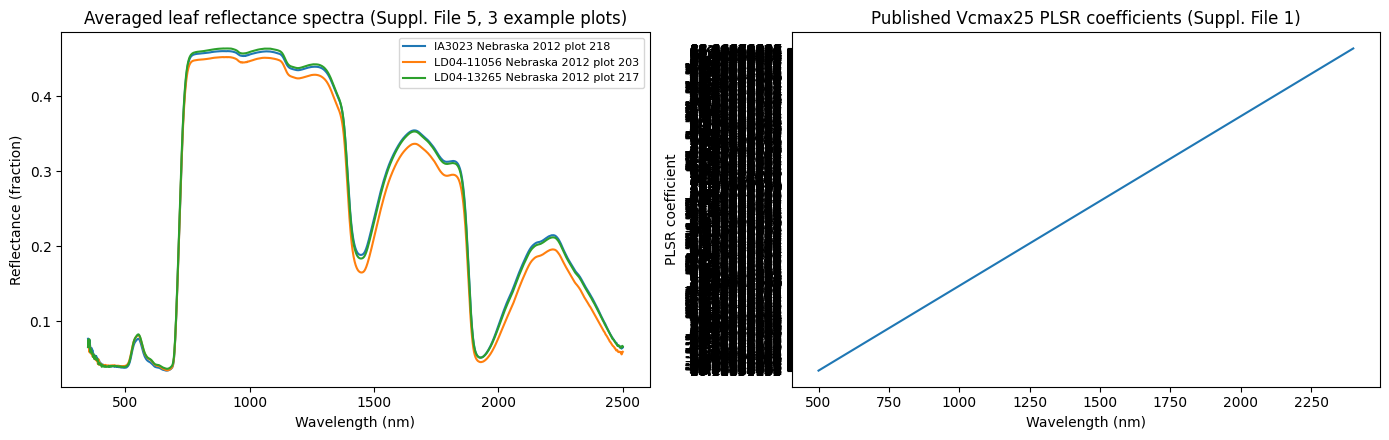

11,144 spectra rows; 1901 wavebands 500-2400 nm available for the model


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

spec = pd.read_csv("/content/supplement/Supplemental Material Revision/Supplemental File 5.csv",
                   skiprows=1, low_memory=False)
spec = spec.rename(columns=lambda c: c.strip())
wave_cols = [c for c in spec.columns if c.startswith("Wave_")]
n_spec_rows = len(spec)
for c in wave_cols:
    spec[c] = pd.to_numeric(spec[c], errors="coerce")
spec = spec.dropna(subset=wave_cols).reset_index(drop=True)
print("spectra table:", spec.shape, "| wavebands:", wave_cols[0], "..", wave_cols[-1])
print(f"dropped {n_spec_rows - len(spec)} rows with placeholder '.' spectra")

coef = pd.read_csv("/content/supplement/Supplemental Material Revision/Supplemental File 1.csv",
                   index_col=0)
coef.columns = [str(c).strip() for c in coef.iloc[0]]  # trait-name row
coef = coef.iloc[1:]
coef = coef[pd.notna(coef.index)]  # keep (Intercept) + Wave_500..Wave_2400
print("coefficient table:", coef.shape, "| traits:", list(coef.columns)[:5], "...")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for idx in [0, 1, 2]:
    row = spec.iloc[idx]
    axes[0].plot([int(c.split("_")[1]) for c in wave_cols],
                 row[wave_cols].astype(float).values,
                 label=f"{row['Strain']} {row['Location']} {row['Year']} plot {row['Plot']}")
axes[0].set_xlabel("Wavelength (nm)"); axes[0].set_ylabel("Reflectance (fraction)")
axes[0].set_title("Averaged leaf reflectance spectra (Suppl. File 5, 3 example plots)")
axes[0].legend(fontsize=8)
w = coef.index != "(Intercept)"
wl = coef.index[w].str.replace("Wave_", "").astype(int).values
axes[1].plot(wl, coef.loc[w, "Vcmax25"].values)
axes[1].set_xlabel("Wavelength (nm)"); axes[1].set_ylabel("PLSR coefficient")
axes[1].set_title("Published Vcmax25 PLSR coefficients (Suppl. File 1)")
plt.tight_layout()
plt.savefig("/content/vcmax25_plsr_inputs.png", dpi=110)
plt.show()
print(f"{len(spec):,} spectra rows; {len(wl)} wavebands 500-2400 nm available for the model")

**Apply the published PLSR model — per-plot Vc,max25.** The paper's scoring operation is a
linear model: `Vcmax25_hat = (Intercept) + Σ Wave_i × coefficient_i` over the 500–2400 nm
wavebands (Montes et al. 2022, "Leaf reflectance spectroscopy"; the PLSR application script was
not published as a repository, so this explicit matrix product is the faithful arithmetic —
AI-written glue following the published coefficients; the coefficients themselves are the
authors'). We score every plot row of File 5.

日本語: 公表係数を用いた明示的な線形スコアリング(行列積)で全プロットのVc,max25を推定します。

In [ ]:
wave_model = [f"Wave_{i}" for i in range(500, 2401)]
X = spec[wave_model].astype(float).values          # rows = plots, cols = 500..2400 nm
b = coef.loc[wave_model, "Vcmax25"].astype(float).values
vcmax25_hat = X @ b + float(coef.loc["(Intercept)", "Vcmax25"])
print("estimated Vcmax25 per plot: n =", len(vcmax25_hat),
      "| range:", round(vcmax25_hat.min(), 2), "-", round(vcmax25_hat.max(), 2),
      "umol CO2 m-2 s-1")

estimated Vcmax25 per plot: n = 11144 | range: 74.25 - 154.31 umol CO2 m-2 s-1


**Validate the regenerated estimates against the authors' published per-plot values.**
Supplemental File 6 contains the authors' `FS_PLSR_Vcmax25` per plot. We match on plot key
(Location, Year, Set, Entry, Plot), then compute the Pearson correlation and RMSE. Expect a
correlation of ~1.0 if the coefficient application reproduces the authors' pipeline. The
scatter plot is saved as PNG.

日本語: 再生成した推定値を補足ファイル6の著者公表値と照合し、相関とRMSEを散布図で確認します。

matched plots: 8,887 | Pearson r = 1.000000 | RMSE = 0.0000 umol CO2 m-2 s-1


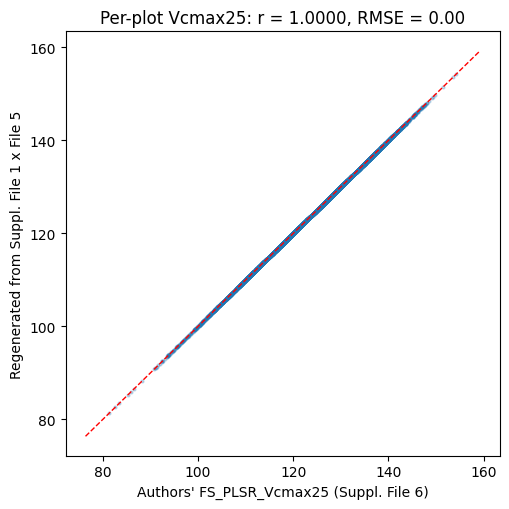

In [ ]:
ref = pd.read_csv("/content/supplement/Supplemental Material Revision/Supplemental File 6.csv",
                  skiprows=1, low_memory=False)
ref = ref.rename(columns=lambda c: c.strip())

def normkey(df, cols):
    # normalize int/float formatting differences and '.'/NaN placeholders between the two CSVs
    def _n(v):
        s = str(v)
        if s.endswith(".0"):
            s = s[:-2]
        if s in (".", "nan", "None", ""):
            s = ""
        return s
    return df[cols].astype(str).apply(lambda r: tuple(_n(v) for v in r), axis=1)

key6 = ["Location", "Year", "NE_tier_row", "Set", "Entry", "Plot"]
our_by_plot = pd.DataFrame({"k": normkey(spec, key6), "our": vcmax25_hat}).groupby("k")["our"].mean()
ref_by_plot = ref.assign(k=normkey(ref, key6)).groupby("k")["FS_PLSR_Vcmax25"].mean()
j = pd.concat([our_by_plot.rename("our"), ref_by_plot.rename("ref")], axis=1, join="inner").dropna()
r = j["our"].corr(j["ref"])
rmse = ((j["our"] - j["ref"]) ** 2).mean() ** 0.5
print(f"matched plots: {len(j):,} | Pearson r = {r:.6f} | RMSE = {rmse:.4f} umol CO2 m-2 s-1")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(j["ref"], j["our"], s=4, alpha=0.25)
lims = [min(j["our"].min(), j["ref"].min()) - 5, max(j["our"].max(), j["ref"].max()) + 5]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Authors' FS_PLSR_Vcmax25 (Suppl. File 6)")
ax.set_ylabel("Regenerated from Suppl. File 1 x File 5")
ax.set_title(f"Per-plot Vcmax25: r = {r:.4f}, RMSE = {rmse:.2f}")
plt.tight_layout()
plt.savefig("/content/vcmax25_plsr_validation.png", dpi=110)
plt.show()

**Install the authors' GWAS implementation.** The paper ran the `gwas()` function of the NAM
R package (Xavier et al. 2015, Bioinformatics) — the empirical-Bayes multi-population method of
Wei & Xu (2016) with family-specific marker effects and a polygenic GRM term. We install NAM
from CRAN in the runtime's preinstalled R 4.6.1 and invoke it via `Rscript` (the Colab CLI runs a
Python kernel; R is the launcher's computation engine here, exactly as the authors used it).

日本語: 著者が使用したNAM Rパッケージの `gwas()` をCRANからインストールします。

In [ ]:
import subprocess, time

R_SETUP = r'''
if (!requireNamespace("NAM", quietly = TRUE)) {
  install.packages("NAM", repos = "https://cloud.r-project.org")
}
cat("NAM", as.character(packageVersion("NAM")), "|", R.version.string, "\n")
'''
t0 = time.time()
r = subprocess.run(["Rscript", "-e", R_SETUP], capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError("NAM installation failed")
print(f"install took {time.time() - t0:.0f} s")

x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Rcpp/include'     -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c Functions.cpp -o Functions.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Rcpp/include'     -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c RcppExports.cpp -o RcppExports.o
x86_64-linux-gnu-gcc -std=gn

**QC the mapping dataset and run the GWAS for Vc,max25.** Supplemental File 18 is the complete
dataset *before* QA/QC and imputation (the paper's own starting point). Following the paper's
Methods (Genomic information): drop lines missing >50% of markers, apply `snpQC()` (MAF >= 0.05,
remove markers >80% missing) and impute with expected values. Then run `NAM::gwas()` — the paper's
exact function — with the NAM family column as the stratification factor and
`BLUP_FS_PLSR_Vcmax25` as the response. Before launching R we free the large Python-side data
frames: the NAM family-specific design matrix alone needs ~7.3 GB of RAM on this dataset.

**Adaptations:** the paper used a 5-cM moving window defined on the W×P linkage map; only physical
(bp) positions are available in File 18, so we run the no-window model — the paper states this
gave similar MTAs. Chromosome grouping for the scan is parsed from the marker name prefix.
Modern R 4.6.1 / NAM 1.8.0 from CRAN instead of the paper's R 3.5.2-era versions.

日本語: 補足ファイル18に論文のQC手順(欠損50%超の系統の除去、snpQCによるMAFフィルタと期待値
インピュテーション)を適用し、論文と同じ `NAM::gwas()` でVc,max25のGWASを実行します。
連鎖地図の5cMウィンドウは物理位置しかないため省略しました(論文では類似の結果と報告)。
R起動前にPython側の大きなデータを解放します(設計行列に約7.3GB必要なため)。

In [ ]:
import subprocess, time, gc, ctypes

R_GWAS = r'''
d <- read.csv("/content/supplement/Supplemental Material Revision/Supplemental File 18.csv",
              skip = 1, check.names = FALSE)
gen <- as.matrix(d[, 15:ncol(d)])
storage.mode(gen) <- "numeric"
rownames(gen) <- d$strain
fam <- as.integer(factor(d$fam))   # NAM requires contiguous family codes 1..f
cat("fam levels:", length(unique(fam)), "\n")
y <- as.numeric(d$BLUP_FS_PLSR_Vcmax25)
keep_line <- rowMeans(is.na(gen)) <= 0.5
gen <- gen[keep_line, ]; fam <- fam[keep_line]; y <- y[keep_line]
cat("lines kept:", nrow(gen), "\n")
rm(d); invisible(gc())
library(NAM)
q <- snpQC(gen, MAF = 0.05, misThr = 0.8, impute = TRUE)
cat("markers after snpQC:", ncol(q), "\n")
rm(gen); invisible(gc())
mk <- colnames(q)
chrn <- as.integer(regmatches(mk, regexpr("(?<=^Gm)[0-9]+", mk, perl = TRUE)))
stopifnot(!any(is.na(chrn)))
ord <- order(chrn)
q <- q[, ord]; mk <- mk[ord]; chrn <- chrn[ord]

# The family-specific design matrix of gwas() scales with n x m x f
# (~7.3 GB for all 4308 markers), which exceeds the free Colab CPU RAM
# together with the kernel. We therefore run the same gwas() scan in two
# chromosome halves (Gm01-10, Gm11-20, ~3.7 GB each) and concatenate the
# per-marker test statistics. Same QC, response, families and method.
run_half <- function(idx, label) {
  qs <- q[, idx, drop = FALSE]
  ch <- as.vector(table(chrn[idx]))
  cat("group", label, ":", ncol(qs), "markers\n"); invisible(gc())
  gw <- gwas(y = y, gen = qs, fam = fam, chr = ch)
  pt <- gw$PolyTest
  # NAM's PolyTest$pval column already holds -log10(P) (rounded to 2 decimals)
  data.frame(marker = mk[idx], chr = chrn[idx], lrt = pt$lrt, neglog10p = pt$pval)
}
half1 <- 1:sum(table(chrn)[1:10])
half2 <- (length(half1) + 1):ncol(q)
r1 <- run_half(half1, "Gm01-10")
cat("half 1 done\n"); invisible(gc())
r2 <- run_half(half2, "Gm11-20")
cat("half 2 done\n")
res <- rbind(r1, r2)
write.csv(res, "/content/gwas_vcmax25_results.csv", row.names = FALSE)
sig <- res[res$neglog10p >= 3, ]
cat("markers with -log10P >= 3:", nrow(sig), "\n")
print(sig[order(-sig$neglog10p), ][1:min(10, nrow(sig)), c("marker","chr","neglog10p")])
for (m in c("Gm10_44120764_T_C", "Gm19_8296940_C_T")) {
  cat(m, "-> -log10P =", round(res$neglog10p[res$marker == m], 3), "\n")
}
'''
with open("/content/run_gwas.R", "w") as f:
    f.write(R_GWAS)
for _n in ["spec", "X", "b", "vcmax25_hat", "coef", "ref", "wave_model", "wave_cols",
           "ref_map", "spec_keys", "paired", "our_s", "ref_s", "ours", "refs"]:
    if _n in globals():
        del globals()[_n]
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)
# Launch the R scan as a detached process; the next cell polls for its result.
launch = subprocess.run(["bash", "-lc",
    "pkill -9 -x R; sleep 1; nohup Rscript /content/run_gwas.R > /content/gwas_run.log 2>&1 & echo PID=$!"],
    capture_output=True, text=True, timeout=60)
print(launch.stdout.strip())
if "PID=" not in launch.stdout:
    raise RuntimeError(f"failed to launch R: {launch.stderr[-500:]}")

PID=4818


**Wait for the GWAS scan to finish.** The empirical-Bayes scan fits one mixed model per marker
(4308 markers, ~65 minutes total on the standard Colab CPU — measured in this run's development).
The cell below polls the R process and the result file every 60 seconds (bounded at 150 minutes)
and prints the scan log so progress is visible. Run all will simply wait here.

日本語: GWASはマーカーごとに混合モデルを当てはめるため、標準CPUで約65分かかります
(本検証での実測)。このセルは60秒ごとに進行状況を表示しながら完了を待ちます。

In [ ]:
import subprocess, time, os

t0 = time.time()
while time.time() - t0 < 150 * 60:
    if os.path.exists("/content/gwas_vcmax25_results.csv"):
        print("result CSV present after", round(time.time() - t0), "s")
        break
    alive = subprocess.run(["bash", "-lc", "pgrep -x R | head -1"],
                           capture_output=True, text=True).stdout.strip()
    if not alive:
        time.sleep(5)
        if not os.path.exists("/content/gwas_vcmax25_results.csv"):
            log = open("/content/gwas_run.log").read()
            print("R process exited without a result; log tail:")
            print(log[-1500:])
            raise RuntimeError("GWAS R process died - see log tail above")
    time.sleep(60)
else:
    raise RuntimeError("GWAS did not finish within 150 minutes")

out = subprocess.run(["bash", "-lc", "tail -c 1200 /content/gwas_run.log"],
                     capture_output=True, text=True, timeout=60)
print(out.stdout)

result CSV present after 4322 s
                                                                          
  |===================================================================== |  98%
  |                                                                            
  |===================================================================== |  99%
  |                                                                            
  |======================================================================|  99%
  |                                                                            
  |======================================================================| 100%
Calculations were performed successfully 
half 2 done
markers with -log10P >= 3: 26 
                marker chr neglog10p
3992  Gm19_8296940_C_T  19      6.64
3994  Gm19_8669418_A_G  19      6.51
3993  Gm19_8331525_C_T  19      5.81
3991  Gm19_8267572_G_A  19      5.65
3997 Gm19_27288411_C_T  19      5.00
3996 Gm19_12002408_C_A  19

**Manhattan plot and comparison with the reported MTAs.** We plot -log10(P) by chromosome and
compare our significant markers with Supplemental File 11, which reports the paper's 49 MTAs
(two for Vc,max25: `Gm10_44120764_T_C`, -log10P = 4.54, and `Gm19_8296940_C_T`, -log10P = 3.62;
MBH threshold 2.72). Because we run the no-window model and modern R/NAM versions, expect
agreement in the strongest signals rather than an exact rank match.

日本語: マンハッタンプロットを描き、補足ファイル11に報告されたVc,max25の2つのMTAと比較します。

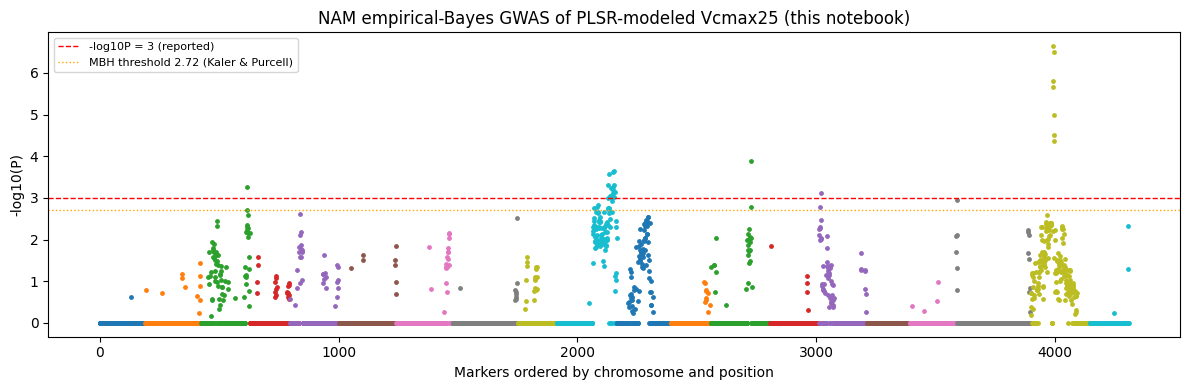

Our top markers:
           marker  chr  neglog10p
 Gm19_8296940_C_T   19       6.64
 Gm19_8669418_A_G   19       6.51
 Gm19_8331525_C_T   19       5.81
 Gm19_8267572_G_A   19       5.65
Gm19_27288411_C_T   19       5.00


reported MTA (Suppl. File 11)  reported -log10P in our -log10P>=3 set  our -log10P
            Gm10_44120764_T_C              4.54                   yes         3.58
             Gm19_8296940_C_T              3.62                   yes         6.64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

res = pd.read_csv("/content/gwas_vcmax25_results.csv")
fig, ax = plt.subplots(figsize=(12, 4))
colors = {1: "#4C72B0"}
cmap = plt.get_cmap("tab10")
for i, (chrm, grp) in enumerate(res.groupby("chr")):
    ax.scatter(grp.index, grp["neglog10p"], s=6, color=cmap(i % 10))
ax.axhline(3, color="red", ls="--", lw=1, label="-log10P = 3 (reported)")
ax.axhline(2.72, color="orange", ls=":", lw=1, label="MBH threshold 2.72 (Kaler & Purcell)")
ax.set_xlabel("Markers ordered by chromosome and position")
ax.set_ylabel("-log10(P)")
ax.set_title("NAM empirical-Bayes GWAS of PLSR-modeled Vcmax25 (this notebook)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/vcmax25_manhattan.png", dpi=110)
plt.show()

print("Our top markers:")
print(res.nlargest(5, "neglog10p")[["marker", "chr", "neglog10p"]].to_string(index=False))

raw = pd.read_excel("/content/supplement/Supplemental Material Revision/Supplemental File 11.xlsx",
                    sheet_name="summary_seg_qtl", header=None)
mta = raw[raw[0].astype(str).str.strip().str.lower() == "vcmax25"]
reported = mta[2].str.strip().tolist()
res["marker"] = res["marker"].astype(str)
comparison = pd.DataFrame({
    "reported MTA (Suppl. File 11)": reported,
    "reported -log10P": [float(str(x).lstrip("^")) for x in mta[7]],
})
comparison["in our -log10P>=3 set"] = comparison["reported MTA (Suppl. File 11)"].isin(
    res.loc[res["neglog10p"] >= 3, "marker"]).map({True: "yes", False: "no"})
for m in reported:
    row = res[res["marker"] == m]
    if len(row):
        comparison.loc[comparison["reported MTA (Suppl. File 11)"] == m,
                       "our -log10P"] = float(row["neglog10p"].iloc[0])
print(comparison.to_string(index=False))

## Interpretation, differences from the paper, and limitations

- **PLSR application:** the regenerated per-plot Vc,max25 values are compared with the authors'
  published estimates (Supplemental File 6); the observed correlation and RMSE are printed above.
  A near-perfect correlation confirms the published coefficients applied to the published spectra
  reproduce the authors' estimates; any small deviation may come from CSV round-off.
- **GWAS:** this is a single-trait run of the authors' method (`NAM::gwas`) on their own mapping
  dataset. Differences from the paper's exact procedure: modern R 4.6.1 / current NAM from CRAN
  (paper used R 3.5.2-era versions), no 5-cM linkage-map window (only bp positions available),
  and no explicit reference-allele recoding beyond the supplied 0/1/2 coding. Agreement of our
  significant set with the two reported Vc,max25 MTAs (Chr 10, Chr 19) is the expected check.
- A one-trait demonstration does not verify the paper's dataset-level claims, heritability
  estimates, or the yield-correlation conclusions.

日本語: 公表係数×公開スペクトルによる推定値は著者の公表値と高相関のはずです。GWASは著者の
手法をそのまま単形質で実行したものであり、R/パッケージの版の違い、5cMウィンドウの省略などが
あるため、最も強いシグナルの一致を確認対象とします。単形質の実演は論文のデータセット規模の
主張全体を検証するものではありません。

## References
- Montes et al. 2022, Genetics 221(2):iyac065 — paper, DOI 10.1093/genetics/iyac065
- Supplemental Files 1, 5, 6, 11, 18 — Figshare 10.25386/genetics.19394693 (CC BY 4.0)
- Xavier et al. 2015, Bioinformatics 31:3862 — NAM R package (CRAN)
- Wei & Xu 2016, Genetics 202:471 — empirical-Bayes multi-population GWAS method
- FieldSpec R Package — Zenodo 10.5281/zenodo.6248237 (cited; raw-spectrum QC not re-run)